# Taxis en Nueva York

## 1. Importar librerias

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Cargar el Dataset

In [2]:
taxis = sns.load_dataset('taxis')
print("Primeras filas del dataset:")
print(taxis.head())
print("\nInformación del dataset:")
print(taxis.info())
print("\nEstadísticas descriptivas:")
print(taxis.describe())

Primeras filas del dataset:
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1 

In [3]:
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [4]:
taxis.info

<bound method DataFrame.info of                   pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment          

## Limpieza de Datos

In [5]:
print("Valores faltantes por columna:")
print(taxis.isnull().sum())

print("\nPorcentaje de valores faltantes:")
print((taxis.isnull().sum() / len(taxis)) * 100)

# Eliminar filas con valores faltantes y crear copia explícita
taxis_clean = taxis.dropna().copy()

print(f"\nDatos originales: {taxis.shape}")
print(f"Datos después de limpieza: {taxis_clean.shape}")

# Verificar duplicados
print(f"\nNúmero de duplicados: {taxis_clean.duplicated().sum()}")

# Convertir columnas de fecha a datetime
taxis_clean['pickup'] = pd.to_datetime(taxis_clean['pickup'])
taxis_clean['dropoff'] = pd.to_datetime(taxis_clean['dropoff'])

# Calcular duración del viaje
taxis_clean['duration'] = (
    taxis_clean['dropoff'] - taxis_clean['pickup']
).dt.total_seconds() / 60

print("\nTipos de datos después de conversión:")
print(taxis_clean.dtypes)

Valores faltantes por columna:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Porcentaje de valores faltantes:
pickup             0.000000
dropoff            0.000000
passengers         0.000000
distance           0.000000
fare               0.000000
tip                0.000000
tolls              0.000000
total              0.000000
color              0.000000
payment            0.683973
pickup_zone        0.404166
dropoff_zone       0.699518
pickup_borough     0.404166
dropoff_borough    0.699518
dtype: float64

Datos originales: (6433, 14)
Datos después de limpieza: (6341, 14)

Número de duplicados: 0

Tipos de datos después de conversión:
pickup             datetime64[ns]
dropoff            datetime64[ns]
passeng

In [6]:
taxis_clean

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duration
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,3.566667
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,56.383333
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,19.116667
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,5.066667


## Análisis Exploratorio de Datos (EDA)

                              pickup                        dropoff  \
count                           6341                           6341   
mean   2019-03-16 08:30:26.574830080  2019-03-16 08:44:47.525784832   
min              2019-02-28 23:29:03            2019-02-28 23:32:35   
25%              2019-03-08 15:28:20            2019-03-08 15:54:00   
50%              2019-03-15 21:57:47            2019-03-15 22:07:48   
75%              2019-03-23 17:45:29            2019-03-23 17:57:56   
max              2019-03-31 23:43:45            2019-04-01 00:13:58   
std                              NaN                            NaN   

        passengers     distance         fare          tip        tolls  \
count  6341.000000  6341.000000  6341.000000  6341.000000  6341.000000   
mean      1.544078     2.997707    12.887931     1.972703     0.314793   
min       0.000000     0.000000     1.000000     0.000000     0.000000   
25%       1.000000     0.990000     6.500000     0.000000     0.

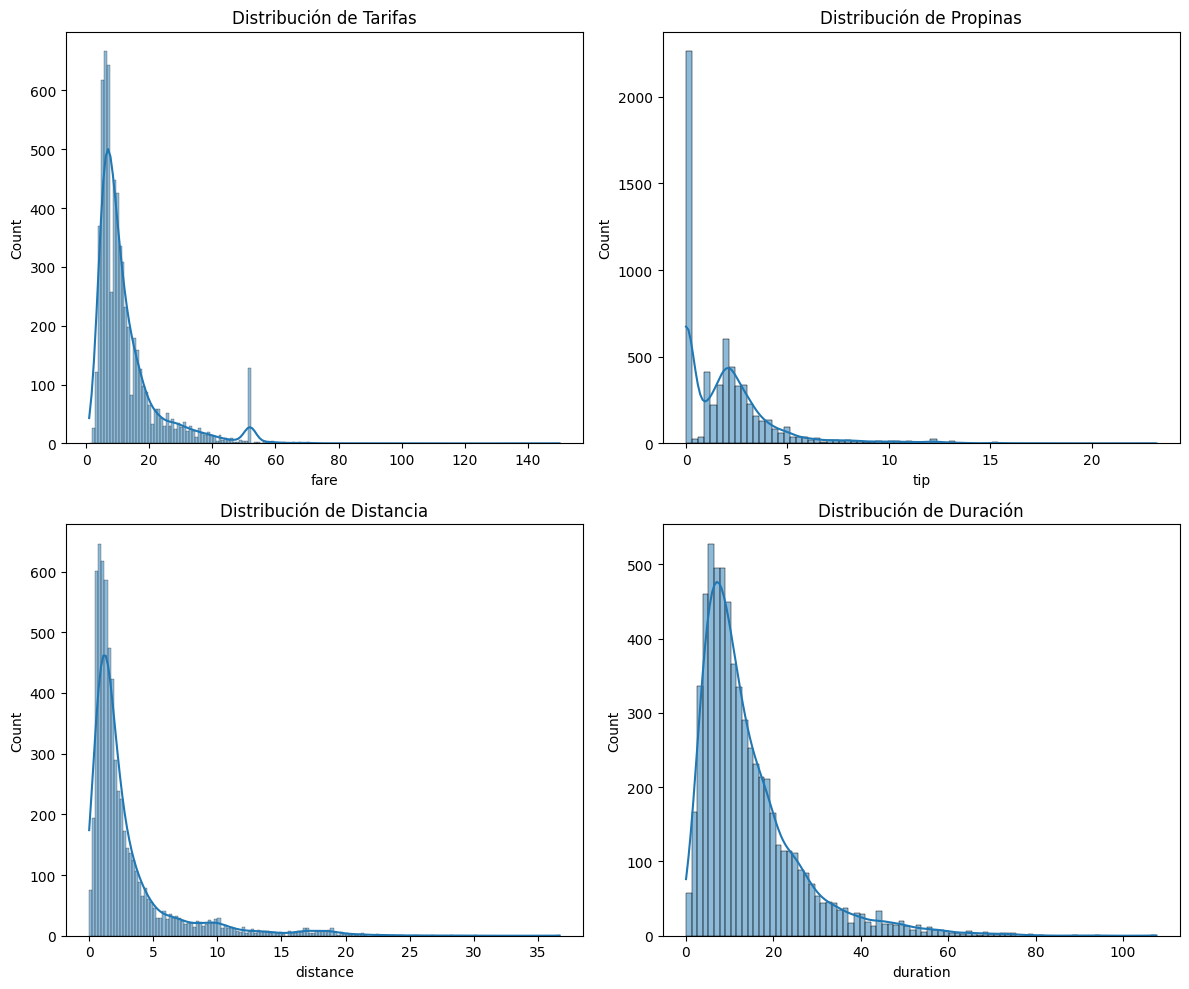

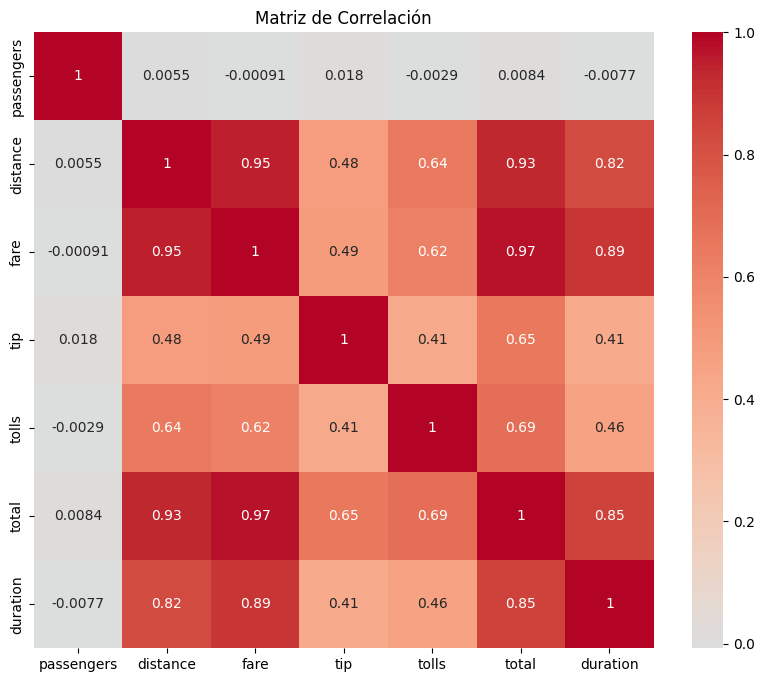

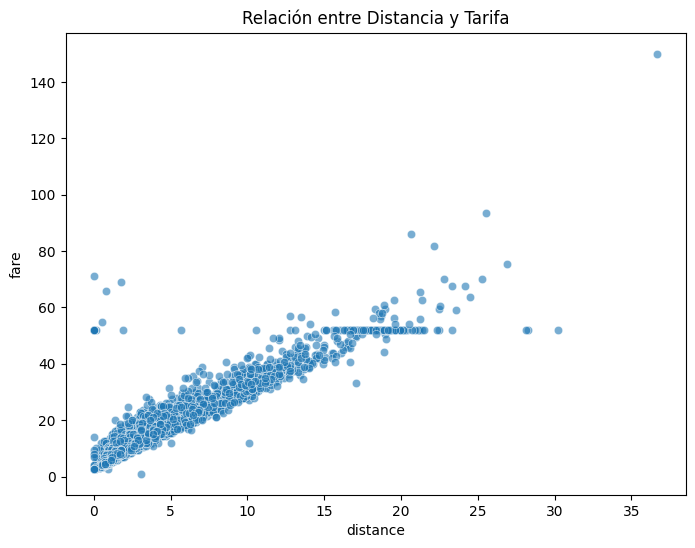

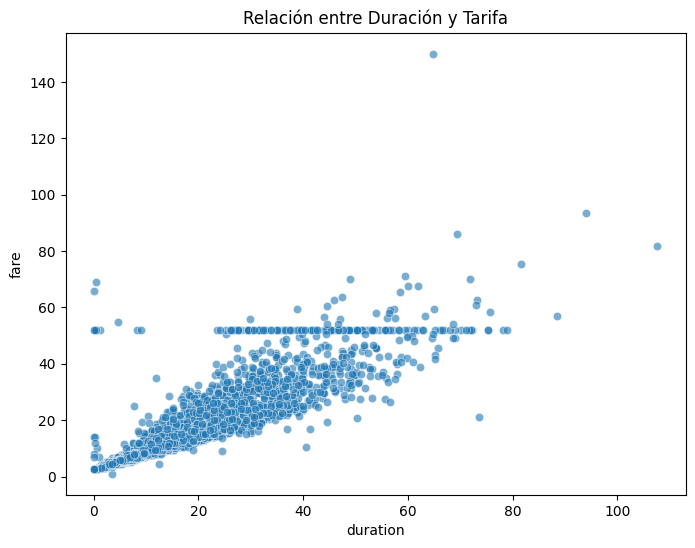

In [7]:
# Estadísticas descriptivas
print(taxis_clean.describe())

# Distribuciones
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(taxis_clean['fare'], ax=axes[0,0], kde=True)
axes[0,0].set_title('Distribución de Tarifas')
sns.histplot(taxis_clean['tip'], ax=axes[0,1], kde=True)
axes[0,1].set_title('Distribución de Propinas')
sns.histplot(taxis_clean['distance'], ax=axes[1,0], kde=True)
axes[1,0].set_title('Distribución de Distancia')
sns.histplot(taxis_clean['duration'], ax=axes[1,1], kde=True)
axes[1,1].set_title('Distribución de Duración')
plt.tight_layout()
plt.show()

# Correlaciones
numeric_cols = taxis_clean.select_dtypes(include=[np.number]).columns
correlation = taxis_clean[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Relaciones
plt.figure(figsize=(8, 6))
sns.scatterplot(data=taxis_clean, x='distance', y='fare', alpha=0.6)
plt.title('Relación entre Distancia y Tarifa')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=taxis_clean, x='duration', y='fare', alpha=0.6)
plt.title('Relación entre Duración y Tarifa')
plt.show()

## 5. Preprocesamiento de datos

In [8]:
# Seleccionar características relevantes para predecir la tarifa
features = ['distance', 'duration', 'passengers', 'pickup_borough', 'dropoff_borough']
X = taxis_clean[features]
y = taxis_clean['fare']

# Codificar variables categóricas
X = pd.get_dummies(X, columns=['pickup_borough', 'dropoff_borough'], drop_first=True)

print("Características seleccionadas:")
print(X.columns.tolist())
print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

# Escalar características numéricas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nDatos escalados: {X_scaled.shape}")

Características seleccionadas:
['distance', 'duration', 'passengers', 'pickup_borough_Brooklyn', 'pickup_borough_Manhattan', 'pickup_borough_Queens', 'dropoff_borough_Brooklyn', 'dropoff_borough_Manhattan', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island']

Forma de X: (6341, 10)
Forma de y: (6341,)

Datos escalados: (6341, 10)


## 6. Dividir

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (5072, 10)
Tamaño del conjunto de prueba: (1269, 10)


## 7 Entrenar el modelo de ML

In [10]:
# Regresión Lineal para predecir la tarifa
model = LinearRegression()
model.fit(X_train, y_train)
print("Modelo entrenado con éxito.")

Modelo entrenado con éxito.


In [11]:
# Guardar el modelo entrenado
import joblib
joblib.dump(model, 'taxi_fare_model.pkl')
print("Modelo guardado como 'taxi_fare_model.pkl'")

# También guardar el scaler para preprocesar nuevas predicciones
joblib.dump(scaler, 'scaler.pkl')
print("Scaler guardado como 'scaler.pkl'")

Modelo guardado como 'taxi_fare_model.pkl'
Scaler guardado como 'scaler.pkl'


## Evaluar el Modelo

Error Cuadrático Medio (MSE): 11.142436148675495
Coeficiente de Determinación (R²): 0.8876885564064749


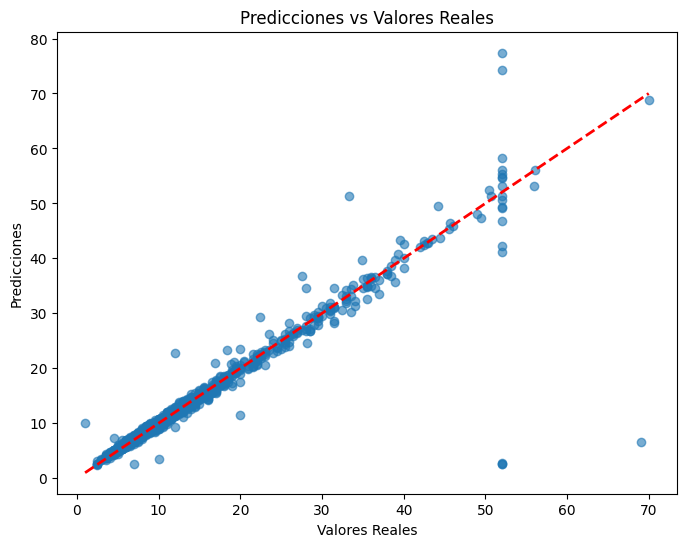


Importancia de características:
                         feature  importance
0                       distance    7.216251
1                       duration    3.635173
8         dropoff_borough_Queens    0.216041
6       dropoff_borough_Brooklyn    0.161872
7      dropoff_borough_Manhattan    0.136954
3        pickup_borough_Brooklyn   -0.049085
5          pickup_borough_Queens    0.034844
9  dropoff_borough_Staten Island    0.027964
4       pickup_borough_Manhattan    0.011666
2                     passengers    0.004410


In [12]:
y_pred = model.predict(X_test)

# Métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error Cuadrático Medio (MSE):", mse)
print("Coeficiente de Determinación (R²):", r2)

# Visualizar predicciones vs valores reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.show()

# Importancia de características
if hasattr(model, 'coef_'):
    feature_names = X.columns
    importance = pd.DataFrame({'feature': feature_names, 'importance': model.coef_})
    importance = importance.sort_values('importance', key=abs, ascending=False)
    print("\nImportancia de características:")
    print(importance)